In [49]:
import spatialdata 
import sopa
import spatialdata_plot
import os

import scanpy as sc
import seaborn as sns

import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import tqdm

In [2]:
rnd_seed = 42

In [3]:
figure_path = '../Figures/sopa_processing'
os.makedirs(figure_path, exist_ok=True)

# Load data

In [4]:
xen_7513 = sopa.read_zarr('../../Xenium_SOPA/P7513/output-XETG00443__0069511__P7513__20250917__131459.zarr/')

version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610:

In [5]:
xen_1212 = sopa.read_zarr('../../Xenium_SOPA/P1212/output-XETG00443__0069529__P1212__20250917__131459.zarr/')

version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610:

In [6]:
mer_7513 = sopa.read_zarr('../../MERSCOPE_SOPA/P7513_sopa/region_R2.zarr/')

version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610:

In [7]:
mer_1212 = sopa.read_zarr('../../MERSCOPE_SOPA/P1212_sopa/region_R1.zarr/')

version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/Users/mathieu/mambaforge/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610:

# MERSCOPE P7513

In [8]:
mer_7513_adata = mer_7513.tables['table'].copy()

In [9]:
mer_7513_adata = mer_7513_adata[mer_7513_adata.obs['area'] > 5000]

In [10]:
pct1, pct99 = np.percentile(mer_7513_adata.obs['area'], q=(1, 99))

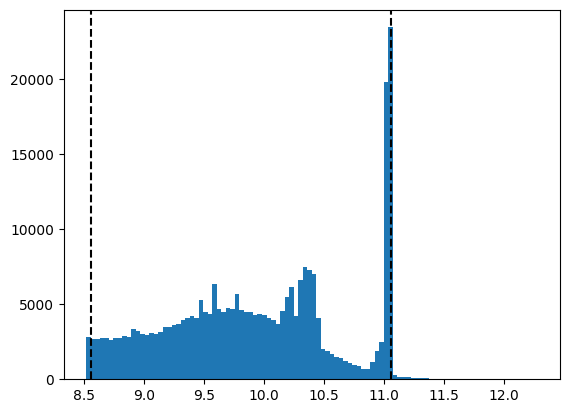

In [11]:
plt.hist(np.log(mer_7513_adata.obs['area']), bins=100)
plt.axvline(x=np.log(pct1), linestyle='dashed', c='k')
plt.axvline(x=np.log(pct99), linestyle='dashed', c='k')
plt.show()

In [12]:
mer_7513_adata.obs['nCounts'] = mer_7513_adata.X.sum(axis=1)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_90849/1164439695.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mer_7513_adata.obs['nCounts'] = mer_7513_adata.X.sum(axis=1)


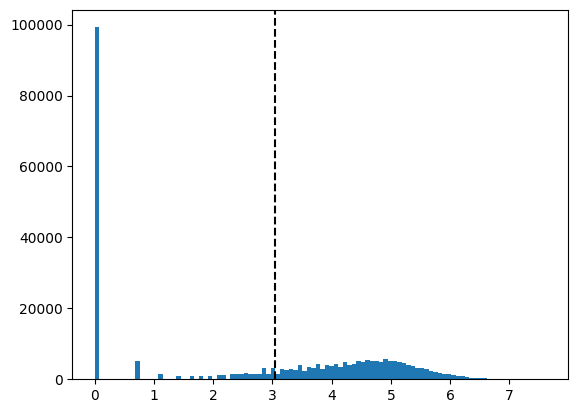

In [13]:
plt.hist(np.log1p(mer_7513_adata.obs['nCounts']), bins=100)
# plt.xlim(0, 750)
plt.axvline(x=np.log1p(20), linestyle='dashed', c='k')
plt.show()

In [14]:
mer_7513_adata = mer_7513_adata[(mer_7513_adata.obs['area'] > pct1) & (mer_7513_adata.obs['area'] < pct99) & (mer_7513_adata.obs['nCounts'] > 20)]

In [15]:
mer_7513_adata.obs['nReads'] = (mer_7513_adata.X > 0).sum(axis=1)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_90849/3513533505.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mer_7513_adata.obs['nReads'] = (mer_7513_adata.X > 0).sum(axis=1)


# Xenium P7513

In [16]:
xen_7513_adata = xen_7513.tables['table'].copy()

In [17]:
xen_7513_adata = xen_7513_adata[xen_7513_adata.obs['area'] > 750]

In [18]:
pct1, pct99 = np.percentile(xen_7513_adata.obs['area'], q=(1, 99))

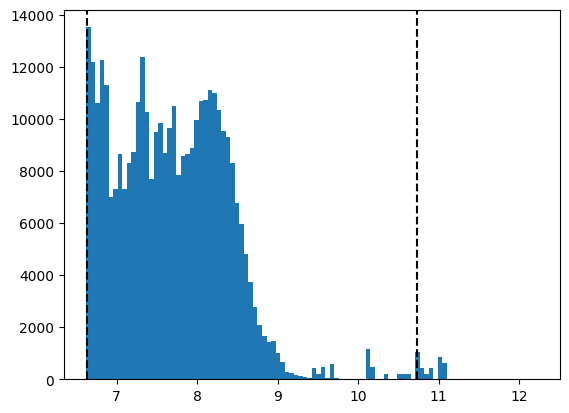

In [19]:
plt.hist(np.log(xen_7513_adata.obs['area']), bins=100)
plt.axvline(x=np.log(pct1), linestyle='dashed', c='k')
plt.axvline(x=np.log(pct99), linestyle='dashed', c='k')
plt.show()

In [20]:
xen_7513_adata.obs['nCounts'] = xen_7513_adata.X.sum(axis=1)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_90849/3002018540.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  xen_7513_adata.obs['nCounts'] = xen_7513_adata.X.sum(axis=1)


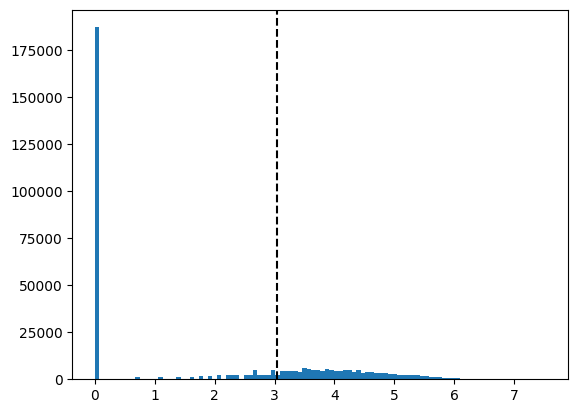

In [21]:
plt.hist(np.log1p(xen_7513_adata.obs['nCounts']), bins=100)
# plt.xlim(0, 750)
plt.axvline(x=np.log1p(20), linestyle='dashed', c='k')
plt.show()

In [22]:
xen_7513_adata = xen_7513_adata[(xen_7513_adata.obs['area'] > pct1) & (xen_7513_adata.obs['area'] < pct99) & (xen_7513_adata.obs['nCounts'] > 20)]

In [23]:
xen_7513_adata.obs['nReads'] = (xen_7513_adata.X > 0).sum(axis=1)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_90849/3180363826.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  xen_7513_adata.obs['nReads'] = (xen_7513_adata.X > 0).sum(axis=1)


# MERSCOPE P1212

In [24]:
mer_1212_adata = mer_1212.tables['table'].copy()

In [25]:
mer_1212_adata = mer_1212_adata[mer_1212_adata.obs['area'] > 5000]

In [26]:
pct1, pct99 = np.percentile(mer_1212_adata.obs['area'], q=(1, 99))

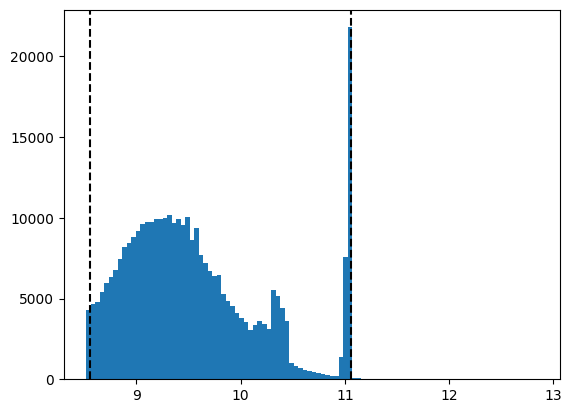

In [27]:
plt.hist(np.log(mer_1212_adata.obs['area']), bins=100)
plt.axvline(x=np.log(pct1), linestyle='dashed', c='k')
plt.axvline(x=np.log(pct99), linestyle='dashed', c='k')
plt.show()

In [28]:
mer_1212_adata.obs['nCounts'] = mer_1212_adata.X.sum(axis=1)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_90849/3808777347.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mer_1212_adata.obs['nCounts'] = mer_1212_adata.X.sum(axis=1)


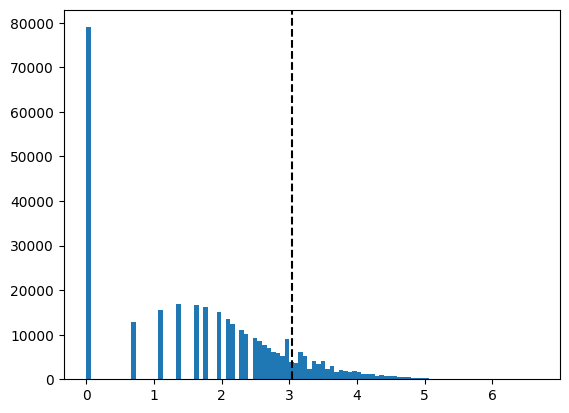

In [29]:
plt.hist(np.log1p(mer_1212_adata.obs['nCounts']), bins=100)
# plt.xlim(0, 750)
plt.axvline(x=np.log1p(20), linestyle='dashed', c='k')
plt.show()

In [30]:
mer_1212_adata = mer_1212_adata[(mer_1212_adata.obs['area'] > pct1) & (mer_1212_adata.obs['area'] < pct99) & (mer_1212_adata.obs['nCounts'] > 20)]

In [31]:
mer_1212_adata.obs['nReads'] = (mer_1212_adata.X > 0).sum(axis=1)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_90849/3299171176.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mer_1212_adata.obs['nReads'] = (mer_1212_adata.X > 0).sum(axis=1)


In [32]:
mer_1212_adata

AnnData object with n_obs × n_vars = 55960 × 300
    obs: 'region', 'slide', 'cell_id', 'area', 'nCounts', 'nReads'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'intensities', 'spatial'

# Xenium P1212

In [33]:
xen_1212_adata = xen_1212.tables['table'].copy()

In [34]:
xen_1212_adata = xen_1212_adata[xen_1212_adata.obs['area'] > 750]

In [35]:
pct1, pct99 = np.percentile(xen_1212_adata.obs['area'], q=(1, 99))

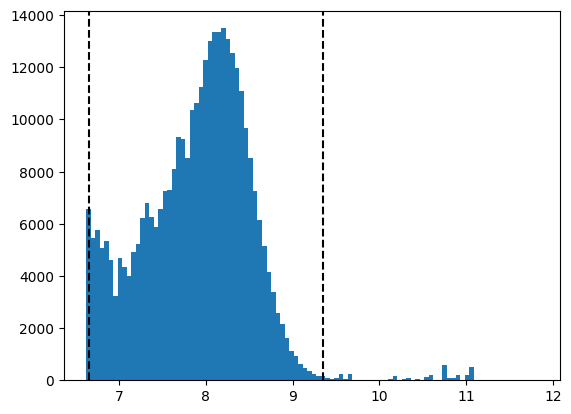

In [36]:
plt.hist(np.log(xen_1212_adata.obs['area']), bins=100)
plt.axvline(x=np.log(pct1), linestyle='dashed', c='k')
plt.axvline(x=np.log(pct99), linestyle='dashed', c='k')
plt.show()

In [37]:
xen_1212_adata.obs['nCounts'] = xen_1212_adata.X.sum(axis=1)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_90849/1672129776.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  xen_1212_adata.obs['nCounts'] = xen_1212_adata.X.sum(axis=1)


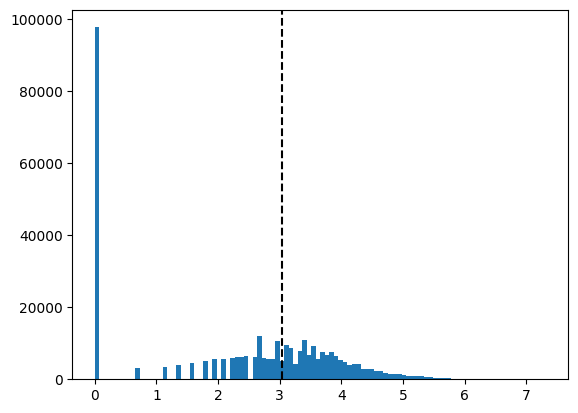

In [38]:
plt.hist(np.log1p(xen_1212_adata.obs['nCounts']), bins=100)
# plt.xlim(0, 750)
plt.axvline(x=np.log1p(20), linestyle='dashed', c='k')
plt.show()

In [39]:
xen_1212_adata = xen_1212_adata[(xen_1212_adata.obs['area'] > pct1) & (xen_1212_adata.obs['area'] < pct99) & (xen_1212_adata.obs['nCounts'] > 20)]

In [40]:
xen_1212_adata.obs['nReads'] = (xen_1212_adata.X > 0).sum(axis=1)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_90849/4196409827.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  xen_1212_adata.obs['nReads'] = (xen_1212_adata.X > 0).sum(axis=1)


In [41]:
xen_1212_adata

AnnData object with n_obs × n_vars = 139824 × 300
    obs: 'region', 'slide', 'cell_id', 'area', 'nCounts', 'nReads'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'intensities', 'spatial'

# Metric Comparison 

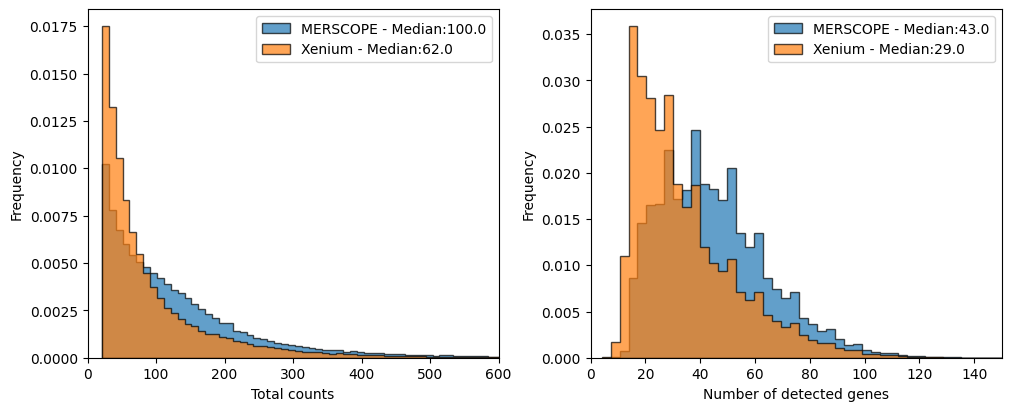

In [42]:
plt.figure(figsize=(10,4), constrained_layout=True)

plt.subplot(121)

mer_med_counts = np.median(mer_7513_adata.obs['nCounts'])
xen_med_counts = np.median(xen_7513_adata.obs['nCounts'])
_, bins, _ = plt.hist(mer_7513_adata.obs['nCounts'], bins=200, density=True, label=f'MERSCOPE - Median:{mer_med_counts}', histtype='stepfilled', edgecolor='k', alpha=0.7)
plt.hist(xen_7513_adata.obs['nCounts'], bins=bins, density=True, label=f'Xenium - Median:{xen_med_counts}', histtype='stepfilled', edgecolor='k', alpha=0.7)
plt.xlim(0,600)
plt.ylabel('Frequency')
plt.xlabel('Total counts')
plt.legend()

plt.subplot(122)

mer_med_nreads = np.median(mer_7513_adata.obs['nReads'])
xen_med_nreads = np.median(xen_7513_adata.obs['nReads'])
_, bins, _ = plt.hist(mer_7513_adata.obs['nReads'], bins=50, density=True, label=f'MERSCOPE - Median:{mer_med_nreads}', histtype='stepfilled', edgecolor='k', alpha=0.7)
plt.hist(xen_7513_adata.obs['nReads'], bins=bins, density=True, label=f'Xenium - Median:{xen_med_nreads}', histtype='stepfilled', edgecolor='k', alpha=0.7)
plt.xlim(0,150)
plt.ylabel('Frequency')
plt.xlabel('Number of detected genes')
plt.legend()

plt.savefig(os.path.join(figure_path,'metric_per_cell_P7513.png'), dpi=300)

plt.show()

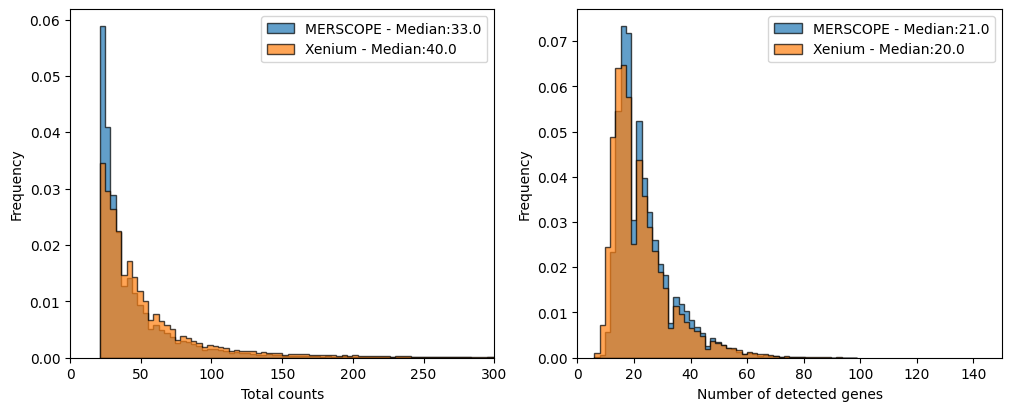

In [43]:
plt.figure(figsize=(10,4), constrained_layout=True)

plt.subplot(121)

mer_med_counts = np.median(mer_1212_adata.obs['nCounts'])
xen_med_counts = np.median(xen_1212_adata.obs['nCounts'])
_, bins, _ = plt.hist(mer_1212_adata.obs['nCounts'], bins=200, density=True, label=f'MERSCOPE - Median:{mer_med_counts}', histtype='stepfilled', edgecolor='k', alpha=0.7)
plt.hist(xen_1212_adata.obs['nCounts'], bins=bins, density=True, label=f'Xenium - Median:{xen_med_counts}', histtype='stepfilled', edgecolor='k', alpha=0.7)
plt.xlim(0,300)
plt.ylabel('Frequency')
plt.xlabel('Total counts')
plt.legend()

plt.subplot(122)

mer_med_nreads = np.median(mer_1212_adata.obs['nReads'])
xen_med_nreads = np.median(xen_1212_adata.obs['nReads'])
_, bins, _ = plt.hist(mer_1212_adata.obs['nReads'], bins=50, density=True, label=f'MERSCOPE - Median:{mer_med_nreads}', histtype='stepfilled', edgecolor='k', alpha=0.7)
plt.hist(xen_1212_adata.obs['nReads'], bins=bins, density=True, label=f'Xenium - Median:{xen_med_nreads}', histtype='stepfilled', edgecolor='k', alpha=0.7)
plt.xlim(0,150)
plt.ylabel('Frequency')
plt.xlabel('Number of detected genes')
plt.legend()

plt.savefig(os.path.join(figure_path,'metric_per_cell_P1212.png'), dpi=300)

plt.show()

# MECR

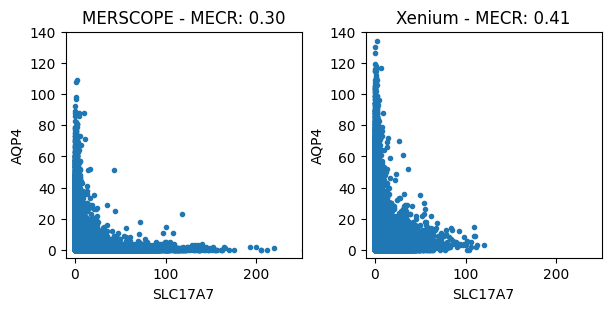

In [44]:
gene1 = 'SLC17A7'
gene2 = 'AQP4'


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,3), constrained_layout=True)

mer_n_both = (mer_7513_adata[:, gene1].X.todense() > 0) & (mer_7513_adata[:, gene2].X.todense() >0)
mer_n_one = (mer_7513_adata[:, gene1].X.todense() > 0) | (mer_7513_adata[:, gene2].X.todense() >0)
mer_mecr = mer_n_both.sum() / mer_n_one.sum()

ax[0].plot(mer_7513_adata[:, gene1].X.todense(), mer_7513_adata[:, gene2].X.todense(), '.') 
ax[0].set_title(f'MERSCOPE - MECR: {mer_mecr:.2f}')
ax[0].set_xlabel(gene1)
ax[0].set_ylabel(gene2)
ax[0].set_ylim(-5,140)
ax[0].set_xlim(-10,250)

xen_n_both = (xen_7513_adata[:, gene1].X.todense() > 0) & (xen_7513_adata[:, gene2].X.todense() >0)
xen_n_one = (xen_7513_adata[:, gene1].X.todense() > 0) | (xen_7513_adata[:, gene2].X.todense() >0)
xen_mecr = xen_n_both.sum() / xen_n_one.sum()

ax[1].plot(xen_7513_adata[:, gene1].X.todense(), xen_7513_adata[:, gene2].X.todense(), '.')
ax[1].set_title(f'Xenium - MECR: {xen_mecr:.2f}')
ax[1].set_xlabel(gene1)
ax[1].set_ylabel(gene2)
ax[1].set_ylim(-5,140)
ax[1].set_xlim(-10,250)

fig.savefig(os.path.join(figure_path, f'{gene1}-{gene2}.png'), dpi=300)

plt.show()

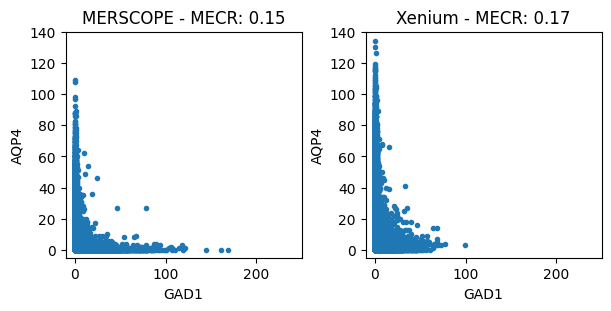

In [96]:
gene1 = 'GAD1'
gene2 = 'AQP4'


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,3), constrained_layout=True)

mer_n_both = (mer_7513_adata[:, gene1].X.todense() > 0) & (mer_7513_adata[:, gene2].X.todense() >0)
mer_n_one = (mer_7513_adata[:, gene1].X.todense() > 0) | (mer_7513_adata[:, gene2].X.todense() >0)
mer_mecr = mer_n_both.sum() / mer_n_one.sum()

ax[0].plot(mer_7513_adata[:, gene1].X.todense(), mer_7513_adata[:, gene2].X.todense(), '.') 
ax[0].set_title(f'MERSCOPE - MECR: {mer_mecr:.2f}')
ax[0].set_xlabel(gene1)
ax[0].set_ylabel(gene2)
ax[0].set_ylim(-5,140)
ax[0].set_xlim(-10,250)

xen_n_both = (xen_7513_adata[:, gene1].X.todense() > 0) & (xen_7513_adata[:, gene2].X.todense() >0)
xen_n_one = (xen_7513_adata[:, gene1].X.todense() > 0) | (xen_7513_adata[:, gene2].X.todense() >0)
xen_mecr = xen_n_both.sum() / xen_n_one.sum()

ax[1].plot(xen_7513_adata[:, gene1].X.todense(), xen_7513_adata[:, gene2].X.todense(), '.')
ax[1].set_title(f'Xenium - MECR: {xen_mecr:.2f}')
ax[1].set_xlabel(gene1)
ax[1].set_ylabel(gene2)
ax[1].set_ylim(-5,140)
ax[1].set_xlim(-10,250)

fig.savefig(os.path.join(figure_path, f'{gene1}-{gene2}.png'), dpi=300)

plt.show()

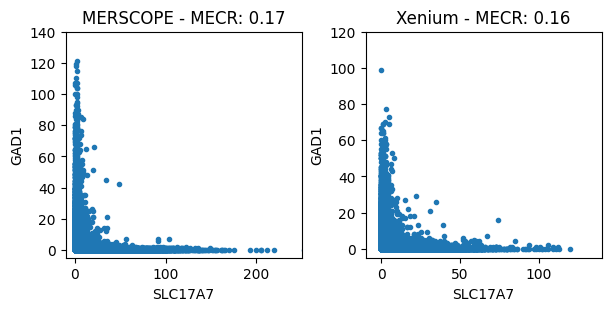

In [99]:
gene1 = 'SLC17A7'
gene2 = 'GAD1'


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,3), constrained_layout=True)

mer_n_both = (mer_7513_adata[:, gene1].X.todense() > 0) & (mer_7513_adata[:, gene2].X.todense() >0)
mer_n_one = (mer_7513_adata[:, gene1].X.todense() > 0) | (mer_7513_adata[:, gene2].X.todense() >0)
mer_mecr = mer_n_both.sum() / mer_n_one.sum()

ax[0].plot(mer_7513_adata[:, gene1].X.todense(), mer_7513_adata[:, gene2].X.todense(), '.') 
ax[0].set_title(f'MERSCOPE - MECR: {mer_mecr:.2f}')
ax[0].set_xlabel(gene1)
ax[0].set_ylabel(gene2)
ax[0].set_ylim(-5,140)
ax[0].set_xlim(-10,250)

xen_n_both = (xen_7513_adata[:, gene1].X.todense() > 0) & (xen_7513_adata[:, gene2].X.todense() >0)
xen_n_one = (xen_7513_adata[:, gene1].X.todense() > 0) | (xen_7513_adata[:, gene2].X.todense() >0)
xen_mecr = xen_n_both.sum() / xen_n_one.sum()

ax[1].plot(xen_7513_adata[:, gene1].X.todense(), xen_7513_adata[:, gene2].X.todense(), '.')
ax[1].set_title(f'Xenium - MECR: {xen_mecr:.2f}')
ax[1].set_xlabel(gene1)
ax[1].set_ylabel(gene2)
ax[1].set_ylim(-5,120)
ax[1].set_xlim(-10,140)

fig.savefig(os.path.join(figure_path, f'{gene1}-{gene2}.png'), dpi=300)

plt.show()

# MECR - P1212

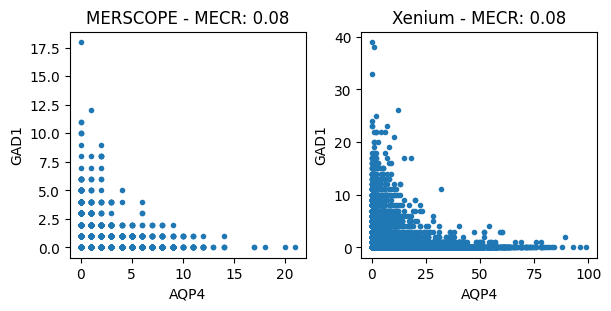

In [129]:
gene1 = 'AQP4'
gene2 = 'GAD1'


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,3), constrained_layout=True)

mer_n_both = (mer_1212_adata[:, gene1].X.todense() > 0) & (mer_1212_adata[:, gene2].X.todense() >0)
mer_n_one = (mer_1212_adata[:, gene1].X.todense() > 0) | (mer_1212_adata[:, gene2].X.todense() >0)
mer_mecr = mer_n_both.sum() / mer_n_one.sum()

ax[0].plot(mer_1212_adata[:, gene1].X.todense(), mer_1212_adata[:, gene2].X.todense(), '.') 
ax[0].set_title(f'MERSCOPE - MECR: {mer_mecr:.2f}')
ax[0].set_xlabel(gene1)
ax[0].set_ylabel(gene2)
# ax[0].set_ylim(-5,140)
# ax[0].set_xlim(-10,250)

xen_n_both = (xen_1212_adata[:, gene1].X.todense() > 0) & (xen_1212_adata[:, gene2].X.todense() >0)
xen_n_one = (xen_1212_adata[:, gene1].X.todense() > 0) | (xen_1212_adata[:, gene2].X.todense() >0)
xen_mecr = xen_n_both.sum() / xen_n_one.sum()

ax[1].plot(xen_1212_adata[:, gene1].X.todense(), xen_1212_adata[:, gene2].X.todense(), '.')
ax[1].set_title(f'Xenium - MECR: {xen_mecr:.2f}')
ax[1].set_xlabel(gene1)
ax[1].set_ylabel(gene2)
# ax[1].set_ylim(-5,140)
# ax[1].set_xlim(-10,250)

# fig.savefig(os.path.join(figure_path, f'{gene1}-{gene2}.png'), dpi=300)

plt.show()

# Selected pairs

In [46]:
pairs = np.load('../../selected_pairs.npy')

In [50]:
xen_mecr = []

for i in tqdm(pairs):
    gene1, gene2 = i[0], i[1]

    if gene1 in list(xen_7513_adata.var.index):
        if gene2 in list(xen_7513_adata.var.index):
            n_both = (xen_7513_adata[:, gene1].X.todense() > 0) & (xen_7513_adata[:, gene2].X.todense() >0)
            n_one = (xen_7513_adata[:, gene1].X.todense() > 0) | (xen_7513_adata[:, gene2].X.todense() >0)
            xen_mecr.append(n_both.sum() / n_one.sum())

  0%|          | 0/19363 [00:00<?, ?it/s]

In [52]:
mer_mecr = []

for i in tqdm(pairs):
    gene1, gene2 = i[0], i[1]
    mer_n_both = (mer_7513_adata[:, gene1].X.todense() > 0) & (mer_7513_adata[:, gene2].X.todense() >0)
    mer_n_one = (mer_7513_adata[:, gene1].X.todense() > 0) | (mer_7513_adata[:, gene2].X.todense() >0)
    mer_mecr.append(mer_n_both.sum() / mer_n_one.sum())

  0%|          | 0/19363 [00:00<?, ?it/s]

In [53]:
cmap = plt.get_cmap('tab10')

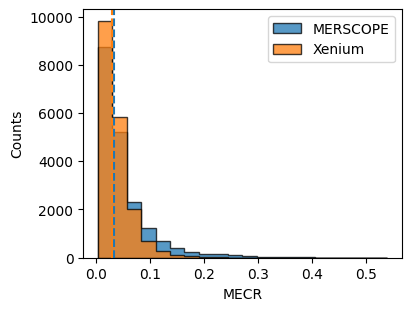

In [54]:
plt.figure(figsize=(4,3), constrained_layout=True)
_, bins, _ = plt.hist(mer_mecr, bins=20, label='MERSCOPE', histtype='stepfilled', edgecolor='k', alpha=0.75)
plt.hist(xen_mecr, bins=bins, label='Xenium', histtype='stepfilled', edgecolor='k', alpha=0.75)
plt.axvline(x=np.median(mer_mecr), linestyle='dashed', c=cmap(0))
plt.axvline(x=np.median(xen_mecr), linestyle='dashed', c=cmap(1))
plt.legend()
plt.xlabel('MECR')
plt.ylabel('Counts')

plt.savefig(os.path.join(figure_path, 'mecr_distribution.png'), dpi=300)

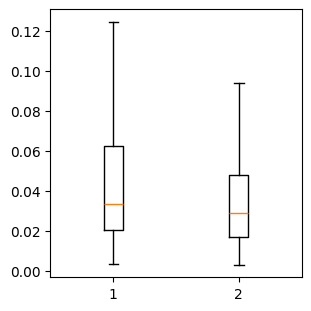

In [ ]:
plt.figure(figsize=(3,3), constrained_layout=True)
plt.boxplot([mer_mecr, xen_mecr], showfliers=False)
plt.show()

In [185]:
np.mean(xen_mecr)

np.float64(0.046170535760686374)